# Task 2: Customer Segmentation Using Unsupervised Learning

This project aims to segment mall customers based on their annual income and spending habits using the K-Means clustering algorithm. Segmentation allows businesses to better understand customer behavior and design targeted marketing strategies.

### Problem Statement
Mall management wants to gain deeper insights into its customer base. Specifically, they aim to identify distinct groups of customers who share similar annual income levels and spending habits.

### Objectives
- Perform Exploratory Data Analysis (EDA) to understand data distribution and relationships.
- Apply the K-Means clustering algorithm to segment customers into meaningful groups.
- Use Principal Component Analysis (PCA) to visualize customer segments clearly.
- Develop tailored marketing strategies for each identified customer segment.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))       
import kagglehub
# Download latest version
path = kagglehub.dataset_download("amisha0528/mall-customers-dataset")
print("Path to dataset files:", path)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Path to dataset files: /kaggle/input/datasets/amisha0528/mall-customers-dataset


## 2. Dataset Description and Loading

The dataset contains the following features:

- **CustomerID**: Unique identification number assigned to each customer.  
- **Genre**: Gender of the customer.  
- **Age**: Age of the customer.  
- **Annual Income (k$)**: Annual income of the customer (in thousands of dollars).  
- **Spending Score (1–100)**: A score assigned by the mall based on customer purchasing behavior and spending patterns.  

This dataset will be loaded into the environment for further preprocessing, analysis, and clustering.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/amisha0528/mall-customers-dataset/Mall_Customers.csv')

# Display basic information
print("Dataset Head:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Head:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


## 3. Data Cleaning and Preprocessing

In this step, we check for missing values and ensure the data is in the correct format.

In [5]:
# Check for null values
print("Missing values in each column:\n", df.isnull().sum())

# No missing values were found. 
# We will focus on 'Annual Income (k$)' and 'Spending Score (1-100)' for clustering.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# It is good practice to scale features for K-Means, though for this specific 
# dataset (where features are on similar scales 15-137 vs 1-100), it's often optional.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing values in each column:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

Visualizing the data helps us identify patterns, trends, and distributions within the dataset.

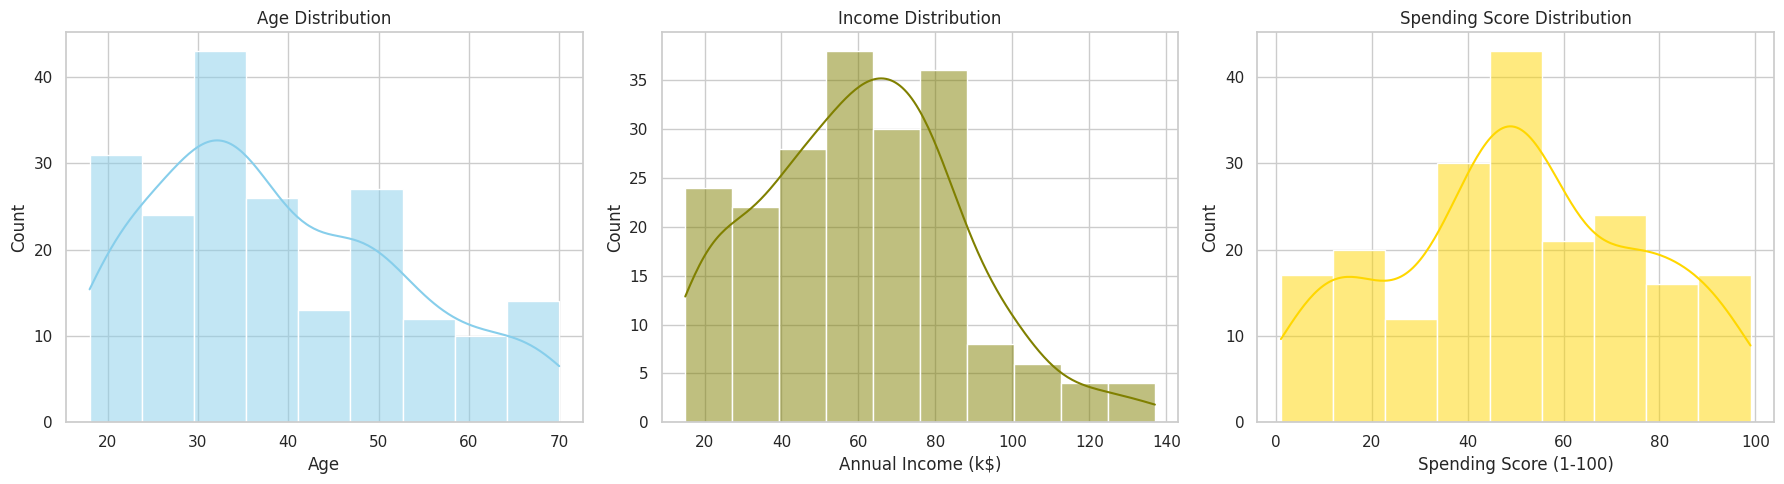

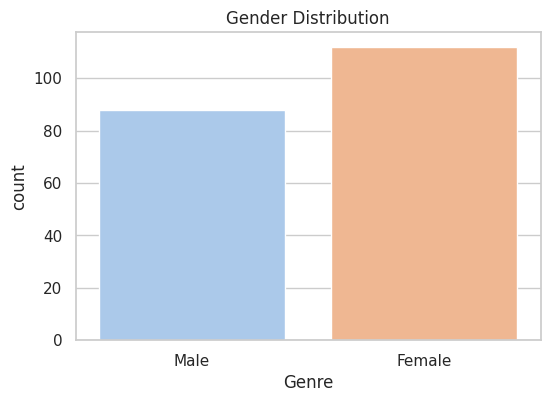

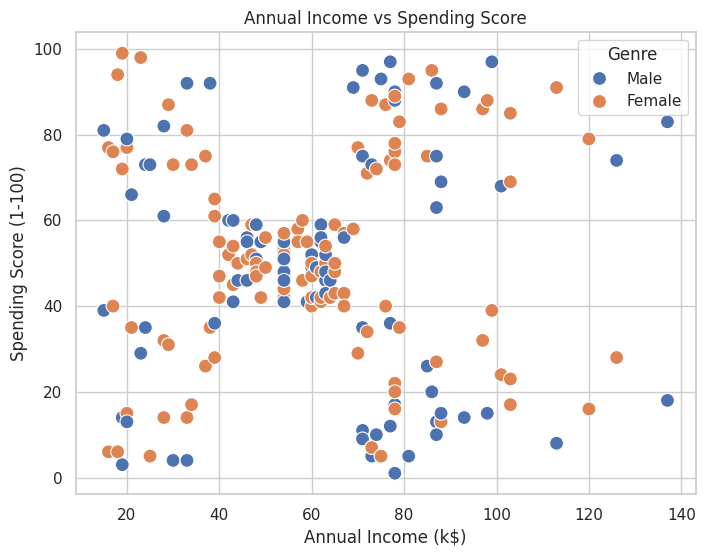

In [7]:
# Set aesthetics
sns.set(style="whitegrid")

# 1. Distribution of Numerical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue').set_title('Age Distribution')
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='olive').set_title('Income Distribution')
sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='gold').set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

# 2. Gender Distribution (Fixed Warning: assigned hue to x and legend=False)
plt.figure(figsize=(6, 4))
sns.countplot(x='Genre', data=df, hue='Genre', palette='pastel', legend=False)
plt.title('Gender Distribution')
plt.show()

# 3. Bivariate Analysis: Income vs Spending
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', data=df, s=100)
plt.title('Annual Income vs Spending Score')
plt.show()


## 5. Model Building and Evaluation  

### Determining Optimal Clusters ($k$)

We use the Elbow Method to identify the optimal number of clusters by observing the point where adding another cluster does not significantly reduce the Within-Cluster Sum of Squares ($WCSS$).

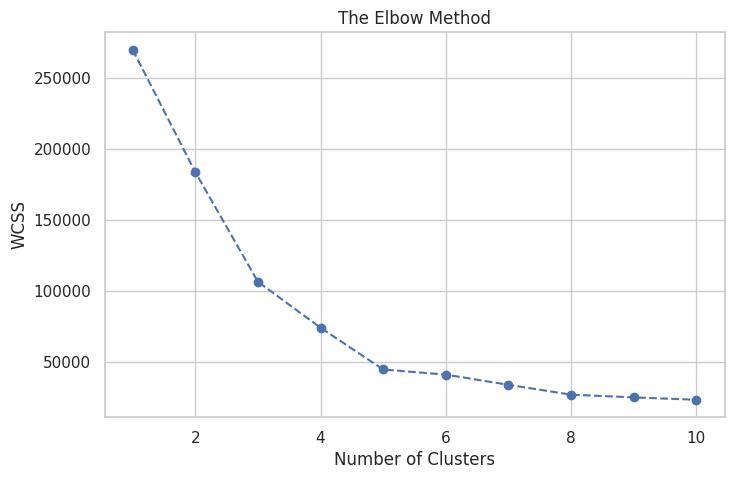

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### Applying $K$-Means

Based on the Elbow plot, the optimal number of clusters is determined to be $k = 5$.

In [10]:
# Training the model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Viewing the clusters
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

print("Cluster Profiles:")
print(cluster_summary)

Cluster Profiles:
         Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                   
0                 55.296296               49.518519     81
1                 86.538462               82.128205     39
2                 25.727273               79.363636     22
3                 88.200000               17.114286     35
4                 26.304348               20.913043     23


## 6. Visualizations (PCA)

We use Principal Component Analysis (PCA) to reduce the data to two dimensions for visual inspection and clearer visualization of the clusters.

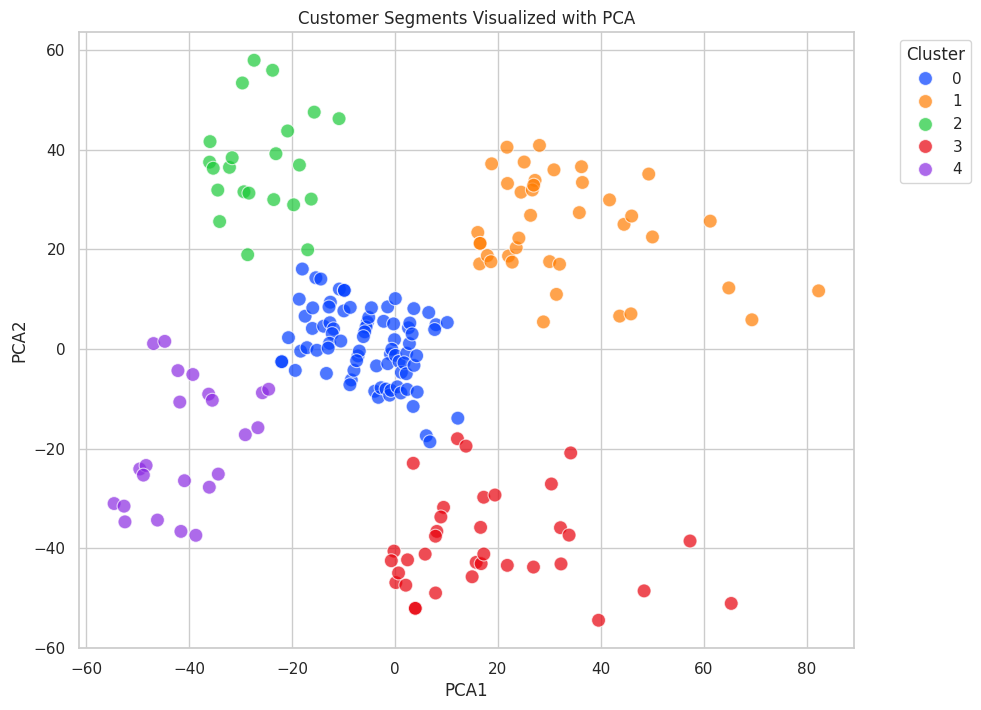

In [11]:
# PCA for Dimensionality Reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plotting the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='bright', s=100, alpha=0.7)
plt.title('Customer Segments Visualized with PCA')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 7. Conclusion and Marketing Insights

### Cluster Analysis

Based on the K-Means clustering, we identified **5 distinct customer segments**:

1. **High Income, High Spending (Stars)**: Wealthy individuals who enjoy shopping frequently.  
2. **High Income, Low Spending (Target)**: High earners who are cautious with their expenditures.  
3. **Low Income, High Spending (Impulsive)**: Lower-income customers who spend a significant portion of their income.  
4. **Low Income, Low Spending (Frugal)**: Budget-conscious customers focused on essentials.  
5. **Middle Income, Middle Spending (Average)**: The most common customer type with moderate spending habits.  

### Marketing Strategies

- **Stars (Cluster 1)**: Implement premium loyalty programs, luxury product launches, and personalized concierge services.  
- **Target (Cluster 3)**: Send personalized discount coupons for luxury items or high-value bundles to encourage spending.  
- **Impulsive (Cluster 2)**: Engage with flash sales, trendy social media campaigns, and "buy now, pay later" offers.  
- **Frugal (Cluster 4)**: Promote budget-friendly value packs, seasonal clearance sales, and basic loyalty rewards.  
- **Average (Cluster 0)**: Maintain engagement with general marketing campaigns, holiday newsletters, and cross-category promotions.